# MSDS 430 Module 7 Python Assignment

<div class="alert alert-block alert-warning"><b>In this assignment you will complete the following exercises and submit your notebook and html file to Canvas. Your files should include all output, i.e. run each cell and save your file before submitting.<b></div>

<div class="alert alert-block alert-info">
    <b>Data dictionaries and an introduction to text analytics:</b><br>
    In this assignment you will work with customer review data for the <b>Sandpiper Inn hotel near Pikes Place</b> in Seattle, Washington. The data is stored in a JSON file. JSON is a popular language-independent data format derived from JavaScript. In fact, JSON stands for JavaScript Object Notation. The load method in the json module in Python can be used to parse a JSON file with result being a Python dictionary. Then by using dictionary methods we can extract the list of reviews for the hotel and then use String methods to get information from within the comments made by the users.<br><br>
<b>Objectives:</b>
    
- Learn about dictionaries and dictionary methods<br>    
- Work with a JSON file<br>
- More about string methods<br>
- Regular expressions - re Module<br>
- Counter module<br>
- Introduction to text analytics and natural language processing (NLP)
</div>

<div class="alert alert-block alert-danger"><b>Reminder: In all of the problems you will see <font color=black>#ToDo</font> statements added as comments on the code cell provided. You will want to be sure to complete each of these as indicated to avoid losing points.</b></div>

In [1]:
# If you never installed TextBlob before you need to run this cell
#!pip install TextBlob

### Import all the modules we are going to need

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import collections
from numpy import mean   

import nltk
from nltk.corpus import stopwords
from nltk import bigrams
from textblob import TextBlob

# set up notebook to display multiple outputs in one cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

### Dictionaries and Dict Methods

The hotel data we want to analyze is contained in the (json) file `sandpiper_reviews.json`. The data includes some information about the hotel, and a number of hotel reviews made by people who (we assume) stayed there. When we read the data into Python we will end up with a "nested" dictionary, i.e. a dictionary some of whose values are also (lists of) dictionaries. Before we examine the structure of this nested dictionary we need to talk a bit about dictionaries in general.

Dictionaries in Python are data structures that store key/value pairs. The keys have to be of an "immutable" type (such as numbers or strings) but the values can be various kinds of things, including lists, arrays, and other dictionaries. The keys need also to be unique: there can't be duplicates. Let us look at some examples.

In [3]:
# A dictionary with keys
dictionary = {1:'Boston',2:'New York',3:'Los Angeles'}
dictionary

{1: 'Boston', 2: 'New York', 3: 'Los Angeles'}

In [4]:
# A dictionary with different types of keys: 1, "two" and (1,2). 
# Here (1,2) is an example of a tuple.
mixed_keys_dict = {1:"one", "two":2, (1,2):"ordered pair" }
mixed_keys_dict

{1: 'one', 'two': 2, (1, 2): 'ordered pair'}

In [5]:
#  Let us define a simple dictionary with String keys: "name", "age" and "sex":
cust_dict = {"name":"Jessica Smith","age": 33, "sex": "F"}
cust_dict

{'name': 'Jessica Smith', 'age': 33, 'sex': 'F'}

The list of keys in a dictionary can be obtained by using the dictionary's `keys` method. Also, we can obtain the value of any key in the dictionary by "bracketing" the key. We could then use assignment to change the value of the key if we wished. For more on this, see __[Dictionary View Objects](https://docs.python.org/3/library/stdtypes.html#dictionary-view-objects)__

In [6]:
# Get the list of keys--actually a dict_keys object (views) in Python 3.x.
cust_dict.keys()

dict_keys(['name', 'age', 'sex'])

In [7]:
# Get the value associated with the "name" key
cust_dict["name"]

'Jessica Smith'

In [8]:
# Change the value of the "name" key
cust_dict["name"] = "Dr. Jessica Smith"

In [9]:
cust_dict

{'name': 'Dr. Jessica Smith', 'age': 33, 'sex': 'F'}

In [10]:
# If a key is not in the dictionary, you get missing
cust_dict.get("height", "missing")

'missing'

In [11]:
# If the key is there it will return its value...
cust_dict.get("name", "missing")

'Dr. Jessica Smith'

We can also use assignment to add new key/value pairs to the dictionary. 

In [12]:
cust_dict['height'] = 5.7
cust_dict['weight'] = 139.5
cust_dict

{'name': 'Dr. Jessica Smith',
 'age': 33,
 'sex': 'F',
 'height': 5.7,
 'weight': 139.5}

Note that we need to add **key/value pairs** to an *existing* dictionary even if the dictionary is empty to begin with...

In [13]:
market_dict = {}  # create an empty dictionary
market_dict['market_name'] = 'Arroyo Deli'
market_dict

{'market_name': 'Arroyo Deli'}

Another __[dictionary method](https://www.w3schools.com/python/python_ref_dictionary.asp)__ that is used to add/modify key/value pairs is the __[update](https://www.w3schools.com/python/ref_dictionary_update.asp)__ dictionary method.

In [14]:
market_dict.update({'market_address': '567 Pine Ave', 'market_phone': '(999)555-6789'})
market_dict

{'market_name': 'Arroyo Deli',
 'market_address': '567 Pine Ave',
 'market_phone': '(999)555-6789'}

Let us add a new key/value pair to `cust_dict`, where the key is `"location"` and the value of that key is another dictionary (with keys: `"city"`, `"state"` and `"zip code"`).

In [15]:
# Example of a nested dictionary...
location_dict = {"city":"Miami","state":"FL","zip code":33165}
cust_dict["location"]=location_dict
cust_dict

{'name': 'Dr. Jessica Smith',
 'age': 33,
 'sex': 'F',
 'height': 5.7,
 'weight': 139.5,
 'location': {'city': 'Miami', 'state': 'FL', 'zip code': 33165}}

Note that the value of the `"location"` key is itself a dictionary and we can access its value by "bracketing" again.

In [16]:
cust_dict['location']

{'city': 'Miami', 'state': 'FL', 'zip code': 33165}

In [17]:
cust_dict['location']['city']

'Miami'

In [18]:
cust_dict['location']['zip code']

33165

<div class="alert alert-block alert-success"><b>Problem 1 (2 pts.)</b>: Add a key/value pair to the <b><i>market_dict</i></b> dictionary defined above. We want the key to be "<b><i>cheese</i></b>" and its corresponding value to be an "inventory" dictionary. This "inventory" dictionary should consist of cheese names as keys (i.e. <b><i>cheddar</i></b>, <b><i>brie</i></b> and <b><i>swiss</i></b>). The value of each key should be the number of such fruits being sold at the market. Assume that there are 123 cheddar, 88 brie and 53 swiss on sale. After adding this key/value pair to <b><i>market_dict</i></b>, display <b><i>market_dict["cheese"]</i></b> to verify your work.</div>

In [19]:
cheese_dict = {"cheddar":123,"brie":88,"swiss":53}

# ToDo: Add a key/value pair to the market_dict where the key is "cheese" and the value cheese_dict
market_dict.update({"cheese":cheese_dict})

# ToDo: Display the keys of 'cheese'
market_dict["cheese"].keys()

# Display the market_dict dictionary
market_dict

dict_keys(['cheddar', 'brie', 'swiss'])

{'market_name': 'Arroyo Deli',
 'market_address': '567 Pine Ave',
 'market_phone': '(999)555-6789',
 'cheese': {'cheddar': 123, 'brie': 88, 'swiss': 53}}

### Examining a JSON File

In [20]:
import json

with open('sandpiper_reviews.json') as json_data:
    hotel_data = json.load(json_data,) 
hotel_data

{'Reviews': [{'Ratings': {'Service': '4',
    'Cleanliness': '5',
    'Overall': '5.0',
    'Value': '4',
    'Sleep Quality': '4',
    'Rooms': '5',
    'Location': '5'},
   'AuthorLocation': 'Boston',
   'Title': '“Excellent Hotel & Location”',
   'Author': 'travel411',
   'ReviewID': 'UR126946257',
   'Content': 'We enjoyed the Sandpiper Inn. My husband and I had a room with a king bed and it was clean, quiet, and attractive. Our sons were in a room with twin beds. Their room was in the corner on the main street and they said it was a little noisier and the neon light shone in. But later hotels on the trip made them appreciate this one more. We loved the old wood center staircase. Breakfast was included and everyone was happy with waffles, toast, cereal, and an egg meal. Location was great. We could walk to shops and restaurants as well as transportation. Pike Market was a reasonable walk. We enjoyed the nearby Gold Rush Museum. Very, very happy with our stay. Staff was helpful and 

The structure of `hotel_data` is a bit complicated but it is divided into two parts: a **HotelInfo** "section" (i.e. the value of the `'HotelInfo'` key) and the **Reviews** "section" (the value of the `'Reviews'` key).

In [21]:
hotel_data.keys()

dict_keys(['Reviews', 'HotelInfo'])

In [22]:
# The hotel information is stored in a dictionary.
hotel_info = hotel_data['HotelInfo']
hotel_info

{'Name': 'Sandpiper Inn PLUS ',
 'HotelURL': '/ShowUserReviews-g60878-d72572-Reviews-Sandpiper_Inn-Seattle_Washington.html',
 'Price': '$117 - $189*',
 'Address': '<address class="addressReset"> <span rel="v:address"> <span dir="ltr"><span class="street-address" property="v:street-address">77 Main Way</span>, <span class="locality"><span property="v:locality">Seattle</span>, <span property="v:region">WA</span> <span property="v:postal-code">98104-2530</span></span> </span> </span> </address>',
 'HotelID': '99999',
 'ImgURL': 'test.jpg'}

In [23]:
# The list of reviews with the data for each review also being stored in a dictionary.
# Here are the first two reviews (dictionaries) in the list...
hotel_data['Reviews'][:2]

[{'Ratings': {'Service': '4',
   'Cleanliness': '5',
   'Overall': '5.0',
   'Value': '4',
   'Sleep Quality': '4',
   'Rooms': '5',
   'Location': '5'},
  'AuthorLocation': 'Boston',
  'Title': '“Excellent Hotel & Location”',
  'Author': 'travel411',
  'ReviewID': 'UR126946257',
  'Content': 'We enjoyed the Sandpiper Inn. My husband and I had a room with a king bed and it was clean, quiet, and attractive. Our sons were in a room with twin beds. Their room was in the corner on the main street and they said it was a little noisier and the neon light shone in. But later hotels on the trip made them appreciate this one more. We loved the old wood center staircase. Breakfast was included and everyone was happy with waffles, toast, cereal, and an egg meal. Location was great. We could walk to shops and restaurants as well as transportation. Pike Market was a reasonable walk. We enjoyed the nearby Gold Rush Museum. Very, very happy with our stay. Staff was helpful and knowledgeable.',
  'Dat

The hotel information is stored in a dictionary (with keys such as `'HotelID'` and `'Address'`), while the reviews are stored in a list--a list of dictionaries, with each dictionary containing information about a particular review. Let us get the list of reviews and save them to the `reviews` variable for further analysis.

In [24]:
reviews = hotel_data['Reviews'] # List of reviews
type(reviews) # Check that it is a list

list

In [25]:
print("There are",len(reviews),"reviews altogether.")

There are 233 reviews altogether.


In [26]:
# Display the first review
first_review = reviews[0] 
first_review

{'Ratings': {'Service': '4',
  'Cleanliness': '5',
  'Overall': '5.0',
  'Value': '4',
  'Sleep Quality': '4',
  'Rooms': '5',
  'Location': '5'},
 'AuthorLocation': 'Boston',
 'Title': '“Excellent Hotel & Location”',
 'Author': 'travel411',
 'ReviewID': 'UR126946257',
 'Content': 'We enjoyed the Sandpiper Inn. My husband and I had a room with a king bed and it was clean, quiet, and attractive. Our sons were in a room with twin beds. Their room was in the corner on the main street and they said it was a little noisier and the neon light shone in. But later hotels on the trip made them appreciate this one more. We loved the old wood center staircase. Breakfast was included and everyone was happy with waffles, toast, cereal, and an egg meal. Location was great. We could walk to shops and restaurants as well as transportation. Pike Market was a reasonable walk. We enjoyed the nearby Gold Rush Museum. Very, very happy with our stay. Staff was helpful and knowledgeable.',
 'Date': 'March 29

In [27]:
# Display first review's ratings only
first_review_ratings = first_review['Ratings']
first_review_ratings

{'Service': '4',
 'Cleanliness': '5',
 'Overall': '5.0',
 'Value': '4',
 'Sleep Quality': '4',
 'Rooms': '5',
 'Location': '5'}

In [28]:
print(first_review['Author'],"made the following comments:",'\n')
print(first_review['Content'])

travel411 made the following comments: 

We enjoyed the Sandpiper Inn. My husband and I had a room with a king bed and it was clean, quiet, and attractive. Our sons were in a room with twin beds. Their room was in the corner on the main street and they said it was a little noisier and the neon light shone in. But later hotels on the trip made them appreciate this one more. We loved the old wood center staircase. Breakfast was included and everyone was happy with waffles, toast, cereal, and an egg meal. Location was great. We could walk to shops and restaurants as well as transportation. Pike Market was a reasonable walk. We enjoyed the nearby Gold Rush Museum. Very, very happy with our stay. Staff was helpful and knowledgeable.


### Creating a List

We want to create a list with just the comments (strings). We do this by iterating over the list of reviews...

In [29]:
comment_lst = []  # This will contain the review strings
for review in reviews:
    comment_lst.append(review['Content'])

In [30]:
len(comment_lst) # Contains 233 comments--one for each reviewer

233

In [31]:
first_comment=comment_lst[0]
print("The first comment in the comment list is:",'\n')
print(first_comment)

The first comment in the comment list is: 

We enjoyed the Sandpiper Inn. My husband and I had a room with a king bed and it was clean, quiet, and attractive. Our sons were in a room with twin beds. Their room was in the corner on the main street and they said it was a little noisier and the neon light shone in. But later hotels on the trip made them appreciate this one more. We loved the old wood center staircase. Breakfast was included and everyone was happy with waffles, toast, cereal, and an egg meal. Location was great. We could walk to shops and restaurants as well as transportation. Pike Market was a reasonable walk. We enjoyed the nearby Gold Rush Museum. Very, very happy with our stay. Staff was helpful and knowledgeable.


### String Methods

We we want to iterate over the list of comments and obtain information about the comments made by the reviewers. Since each of the comments is a String object, we are going to need some String methods to extract the information. See, for example, __[String Methods](https://www.w3schools.com/python/python_ref_string.asp)__. Let us illustrate some of the listed methods with the comments from the first reviewer.

In [32]:
# Create a new string with all characters made lower case.
first_comment.lower()

'we enjoyed the sandpiper inn. my husband and i had a room with a king bed and it was clean, quiet, and attractive. our sons were in a room with twin beds. their room was in the corner on the main street and they said it was a little noisier and the neon light shone in. but later hotels on the trip made them appreciate this one more. we loved the old wood center staircase. breakfast was included and everyone was happy with waffles, toast, cereal, and an egg meal. location was great. we could walk to shops and restaurants as well as transportation. pike market was a reasonable walk. we enjoyed the nearby gold rush museum. very, very happy with our stay. staff was helpful and knowledgeable.'

In [33]:
# Find how many times the string "we" is mentioned in the comments.
first_comment.count("we")

2

In [34]:
# If we wanted a "case-insensitive" search of instances of "we", we can do this.
first_comment.lower().count("we")  # include "We" as well

6

<div class="alert alert-block alert-success"><b>Problem 2 (2 pts.)</b>: 
    
Complete the loop below to display the number of times the word `business` is contained within the text of the reviews for this hotel. Your output should look like this:</div>

`The word 'business' occurs 22 times in the reviews for this hotel.`

In [35]:
counter = 0
for review in comment_lst:
    # ToDo: Insert code in the for loop body to determine the number of times "business" appears 
    # in the current review and increment the counter variable accordingly.
    counter += review.lower().count("business")
        
# ToDo: Print the result using an f-string
print(f"The word 'business' occurs {counter} times in the reviews for this hotel.")

The word 'business' occurs 22 times in the reviews for this hotel.


<div class="alert alert-block alert-success"><b>Problem 3 (2 pts.)</b>: Print the number of "wordy" comments. A comment is considered "wordy" if it contains more than 125 words. For example, "We stayed here and we liked it" contains 7 words. Your output should look like this:</div>

`There are 94 wordy comments.`

In [36]:
counter = 0
for review in comment_lst:
    # ToDo: Insert code in the for loop body to get the number of "wordy" comments.
    if len(review.split()) > 125:
        counter += 1

# ToDo: Print the number of wordy comments.
print(f"There are {counter} wordy comments.")

There are 94 wordy comments.


We want to iterate over the `reviews` dictionary again this time saving the name of the reviewer together with the comments (in a dictionary).

<div class="alert alert-block alert-success"><b>Problem 4 (4 pts.)</b>: Create a list of dictionaries (<b><i>ar_dict</i></b>), where each dictionary has two keys: "<b><i>Author</i></b>" and "<b><i>Comments</i></b>". Iterate over the list of reviews and for each review construct a dictionary containing the author's name and one containing comments. Next append them to the list of dictionaries we are creating. Print the number of elements in the list. Your output should look like this:</div>

`There are 233 elements in the list.`

In [37]:
review_list = []
for review in reviews:
    # ToDo: (1) Create a dictionary, ar_dict, containing just two keys, “Author” and "Comments”. 
    #           Their values should be obtained from the current review dictionary stored in the “review” variable.
    #       (2) Append this newly constructed dictionary, ar_dict, to the review_list.
    ar_dict = {"Author":review["Author"],"Comments":review["Content"]}
    review_list.append(ar_dict)
    

# ToDo: Print the number of elements in 'review_list' as demonstrated above.
print(f"There are {len(review_list)} elements in the list.")

There are 233 elements in the list.


Display the first two elements of `review_list` so you can see the dictionary structure you created.

In [38]:
review_list[0:2]

[{'Author': 'travel411',
  'Comments': 'We enjoyed the Sandpiper Inn. My husband and I had a room with a king bed and it was clean, quiet, and attractive. Our sons were in a room with twin beds. Their room was in the corner on the main street and they said it was a little noisier and the neon light shone in. But later hotels on the trip made them appreciate this one more. We loved the old wood center staircase. Breakfast was included and everyone was happy with waffles, toast, cereal, and an egg meal. Location was great. We could walk to shops and restaurants as well as transportation. Pike Market was a reasonable walk. We enjoyed the nearby Gold Rush Museum. Very, very happy with our stay. Staff was helpful and knowledgeable.'},
 {'Author': 'Betty W',
  'Comments': 'Great visit to Seattle thanks to our stay at the Sandpiper Inn! The hotel was reasonably priced and close to everything we wanted to see - ferry ride, Underground Tour, Klondike Museum, short walk to Pike Market and other 

In [39]:
# Let us display the data from the first dictionary in the list.

first_review = review_list[0]
print(f"{first_review['Author']}, said this",'\n')

print(first_review['Comments'])

travel411, said this 

We enjoyed the Sandpiper Inn. My husband and I had a room with a king bed and it was clean, quiet, and attractive. Our sons were in a room with twin beds. Their room was in the corner on the main street and they said it was a little noisier and the neon light shone in. But later hotels on the trip made them appreciate this one more. We loved the old wood center staircase. Breakfast was included and everyone was happy with waffles, toast, cereal, and an egg meal. Location was great. We could walk to shops and restaurants as well as transportation. Pike Market was a reasonable walk. We enjoyed the nearby Gold Rush Museum. Very, very happy with our stay. Staff was helpful and knowledgeable.


### The Counter Module

In the next exercise we want to count the number of *unique* words in each of the comments. We learned previously how to split a string to create a list of words. We can write code from scratch to count the number of different words in the list. Alternatively, we can convert the list to another container data type that makes it easier to obtain this information. The `counter` module defines the `Counter` class. A `Counter` is basically a "special type" of dictionary. Given a list object `my_list` we can turn it into a counter object as follows: `Counter(my_list)`. This assumes we already imported the class from the collections module: `from collections import Counter`. See __[Counter Module](http://rahmonov.me/posts/python-collections-counter/)__. 

For example,

```python
from collections import Counter
my_list = ['a', 'b', 'c', 'c', 'a', 'd', 'b', 'e', 'a']
Counter(my_list)
```
creates the Counter object:

```python
Counter({'a': 3, 'b': 2, 'c': 2, 'd': 1, 'e': 1})
```

This tells you that the letter `a` appears `3` times in the list, etc.

We can get the keys and values just like with dictionaries:

```python
list(Counter(my_list).keys())
```

returns

```python
['a', 'b', 'c', 'd', 'e']
```

and

```python
list(Counter(my_list).values())
```

returns

```python
[3, 2, 2, 1, 1]
```

### Regular Expressions - The *re* Module

Regular expressions or regexes are a specialized programming language embedded inside Python and made available through the `re` module. Using *re* module functions, you specify the rules for the set of possible strings that you want to match. You can follow this up with questions such as “Does this string match the pattern?”, or “Is there a match for the pattern anywhere in this string?”. You can also use regexes (or REs) to modify a string or to split it apart in various ways.

Reference: __[Regex How-to](https://docs.python.org/3.7/howto/regex.html#regex-howto)__

In our specific example, we want to get the list of words in each review. The first step towards this goal is to remove punctuation from the comment strings. There is top-level function `sub` in the `re` module that can be used to replace characters in a string by other characters (or remove them altogether).

In [40]:
import re

phone = "888-333-1234 # This is Phone Number"

# Delete Python-style comments after the #
num = re.sub(r'#.*$', "", phone)
print("Phone Num : ", num)

# Remove anything other than digits
num = re.sub(r'\D', "", phone)    
print("Phone Num : ", num)

Phone Num :  888-333-1234 
Phone Num :  8883331234


For more examples on regular expressions, please visit: <br>__[Regular Expressions](https://www.tutorialspoint.com/python/python_reg_expressions.htm)__

For a list of punctuation options in the string class, please visit:<br>
__[String Punctuation](https://www.geeksforgeeks.org/string-punctuation-in-python/)__

In [41]:
import string
# Contains the most common characters found in text
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

<div class="alert alert-block alert-success"><b>Problem 5 (4 pts.)</b>: Iterate over <b><i>review_list</i></b> and print the name of each reviewer (author) and the total number of *different*, i.e. *unique*, words in his comments. For example, "We stayed here and we liked it" contains 6 *unique* words since 'we' is repeated 2 times.

As part of the process of counting *unique* words in each comment string you want to first remove all punctuation using `re.sub`. Save the resulting string to a list: `comments`. </b> 
    
</div>

##### Sample Output

In [42]:
counter = 0
from collections import Counter
import re
comments = []
for review in review_list:
    # ToDo: (1) Get the number of words in the current review variable.
    #       (2) Print the author's name and the number of (unique) words in his/her review 
    cleaned = re.sub(f'[{re.escape(string.punctuation)}]', ' ', review["Comments"]).lower()
    comments.append(cleaned)
    unique_count = len(Counter(cleaned.split()))
    print(f"{review["Author"]} used {unique_count} unique words.")

travel411 used 85 unique words.
Betty W used 82 unique words.
Monica Z used 44 unique words.
JackFlorida used 69 unique words.
JoshArmstrong_BC used 106 unique words.
Shazzer33333 used 52 unique words.
Bnkruzn used 15 unique words.
Teachercobra used 54 unique words.
CandyCandy used 50 unique words.
idahoshirley used 16 unique words.
CW2S used 143 unique words.
jimmy66_11 used 78 unique words.
Boulder2222 used 130 unique words.
funlovingdmom used 103 unique words.
suntravelerUS used 205 unique words.
rosariodurao used 39 unique words.
Jody K used 87 unique words.
Sasha M used 27 unique words.
Roy Cat used 88 unique words.
MikeGB used 107 unique words.
Jennie S used 55 unique words.
mcdonothing used 81 unique words.
SWanjiru used 108 unique words.
trish0 used 50 unique words.
txlnstr used 26 unique words.
mydogisfat used 46 unique words.
DaddyHoward used 96 unique words.
BCisBeautiful used 120 unique words.
wildorchid416 used 173 unique words.
JCPCG used 82 unique words.
quilter1975 used

## Analyzing the Review text

The next step in analyzing the data is to look for insights within the reviews given by the customers. We will start by looking at the most common words and then analyzing the sentiments of the reviews - whether they are positive or negative.

In [43]:
# Start with the list of Reviews which is in a free text format 
type(comments)
len(comments) # Number of comments
comments[:3] # Display the first three comments in the list

list

233

['we enjoyed the sandpiper inn  my husband and i had a room with a king bed and it was clean  quiet  and attractive  our sons were in a room with twin beds  their room was in the corner on the main street and they said it was a little noisier and the neon light shone in  but later hotels on the trip made them appreciate this one more  we loved the old wood center staircase  breakfast was included and everyone was happy with waffles  toast  cereal  and an egg meal  location was great  we could walk to shops and restaurants as well as transportation  pike market was a reasonable walk  we enjoyed the nearby gold rush museum  very  very happy with our stay  staff was helpful and knowledgeable ',
 'great visit to seattle thanks to our stay at the sandpiper inn  the hotel was reasonably priced and close to everything we wanted to see   ferry ride  underground tour  klondike museum  short walk to pike market and other shopping  the staff was amazingly helpful and accommodating  our room was v

## Tokenize - or split into words

The `comments` list has already been cleaned with lower case and all punctuation removed. But the cell below shows the combined use of `.lower` to normalize the case of the data and `.split` to use the white space of the sentences to establish words (tokens).

In [44]:
# Break out the Reviews into words
my_words = [line.lower().split() for line in comments]

# Display the first 10 words in the first 5 comments
for words in my_words[:5]:
    print(words[:10])

['we', 'enjoyed', 'the', 'sandpiper', 'inn', 'my', 'husband', 'and', 'i', 'had']
['great', 'visit', 'to', 'seattle', 'thanks', 'to', 'our', 'stay', 'at', 'the']
['great', 'location', 'short', 'walk', 'from', 'amtrak', 'station', 'link', 'or', 'to']
['accommodation', 'in', 'seattle', 'can', 'be', 'expensive', 'this', 'hotel', 'is', 'very']
['very', 'cool', 'old', 'building', 'in', 'a', 'great', 'location', 'check', 'in']


### Itertools - a standard python package that allows for iterating instead of looping

 * __[jmduke itertools](https://jmduke.com/2013/11/29/itertools)__
 * __[realpython itertools](https://realpython.com/python-itertools/)__

In [45]:
# Prepare the words for analysis
words_total = list(itertools.chain(*my_words))

type(words_total)
words_total[:20] # Display the first 20 words in the comments


list

['we',
 'enjoyed',
 'the',
 'sandpiper',
 'inn',
 'my',
 'husband',
 'and',
 'i',
 'had',
 'a',
 'room',
 'with',
 'a',
 'king',
 'bed',
 'and',
 'it',
 'was',
 'clean']

### Most common words

When you look at the most common words, you see words that are not unique to hotel reviews, but are common to any topic like <i><u> the, and, a, to.</i></u> In Natural Language Processing, these are called <b>stopwords</b>.

When you run the following cell, you can see the most common words are what would qualify as stopwords. These stopwords have no value in our analysis and only provide noise.

In [46]:
# You can see the most common words are what would qualify as stopwords
# These stopwords have no value in our analysis and only provide noise
count_words = collections.Counter(words_total)
count_words.most_common(20)

[('the', 2108),
 ('and', 1194),
 ('a', 893),
 ('to', 864),
 ('was', 682),
 ('of', 505),
 ('we', 497),
 ('hotel', 476),
 ('is', 468),
 ('in', 462),
 ('i', 426),
 ('for', 359),
 ('it', 323),
 ('very', 280),
 ('this', 260),
 ('room', 256),
 ('with', 254),
 ('at', 229),
 ('were', 224),
 ('you', 208)]

### Stopwords

The <b>nltk</b> package comes with default stopwords.

In [47]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Comes with 179 stopwords
len(stop_words)
stop_words

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shidesh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

198

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

### Remove stopwords

The code in the next cell will remove the stopwords from your list.

In [48]:
my_final = [[word for word in count_words if not word in stop_words]
              for count_words in my_words]
my_final

[['enjoyed',
  'sandpiper',
  'inn',
  'husband',
  'room',
  'king',
  'bed',
  'clean',
  'quiet',
  'attractive',
  'sons',
  'room',
  'twin',
  'beds',
  'room',
  'corner',
  'main',
  'street',
  'said',
  'little',
  'noisier',
  'neon',
  'light',
  'shone',
  'later',
  'hotels',
  'trip',
  'made',
  'appreciate',
  'one',
  'loved',
  'old',
  'wood',
  'center',
  'staircase',
  'breakfast',
  'included',
  'everyone',
  'happy',
  'waffles',
  'toast',
  'cereal',
  'egg',
  'meal',
  'location',
  'great',
  'could',
  'walk',
  'shops',
  'restaurants',
  'well',
  'transportation',
  'pike',
  'market',
  'reasonable',
  'walk',
  'enjoyed',
  'nearby',
  'gold',
  'rush',
  'museum',
  'happy',
  'stay',
  'staff',
  'helpful',
  'knowledgeable'],
 ['great',
  'visit',
  'seattle',
  'thanks',
  'stay',
  'sandpiper',
  'inn',
  'hotel',
  'reasonably',
  'priced',
  'close',
  'everything',
  'wanted',
  'see',
  'ferry',
  'ride',
  'underground',
  'tour',
  'klond

In [49]:
all_words = list(itertools.chain(*my_final))
counts_all = collections.Counter(all_words)
counts_all.most_common(20)

[('hotel', 476),
 ('room', 256),
 ('seattle', 203),
 ('staff', 173),
 ('place', 172),
 ('great', 166),
 ('breakfast', 160),
 ('pike', 148),
 ('stay', 140),
 ('location', 112),
 ('good', 105),
 ('clean', 104),
 ('square', 103),
 ('friendly', 94),
 ('would', 92),
 ('free', 91),
 ('walk', 90),
 ('helpful', 90),
 ('us', 89),
 ('one', 87)]

Let's take a look of the results of removing the stopwords.  You can see (in the cell above) words common to our topic appearing at the top of the list. <br>

Does the word 'hotel' add anything to our analysis?  Probably not since we are dealing with hotel reviews. Cleaning text for analysis is very topic specific and requires that you either include discussion with a subject matter expert or spend time with the data to discover the words common to the topic; in our case it is words like `hotel` and `room`. Let's remove these words that will not add to our analysis.  Below is sample code showing how to add to the out-of-the-box stopwords.

In [50]:
len(stop_words)

type(stop_words)

# Add in common words that you don't want in analysis
my_stop = ['hotel','room']

stop_words.update(my_stop)

len(stop_words)

198

set

200

<div class="alert alert-block alert-success"><b>Problem 6 (6 pts.)</b>:  
    
Looking at the most common words, which words will **not** add to the analysis?<br>

1. Add 'seattle', 'sandpiper' and 'inn' to the stopword list. Show the len of `stop_words` before and after you add the stopwords.
2. Apply your new stopword list to the review list.
3. Show the most common 20 words

</div>

<div class="alert alert-block alert-success"><b>Problem 6 (part 1)</b>:  
    
Add 'seattle', 'sandpiper' and 'inn' to the stopword list. Show the len of `stop_words` before and after you add the stopwords.
</div>

In [51]:
#ToDo: Show the length of stop_words before adding to the stopword list
len(stop_words)

#ToDo: Add 'seattle', 'sandpiper' and 'inn'  to the stopword list
stop_words.update(['seattle', 'sandpiper', 'inn'])

#ToDo: Show the length of 'stop_words' after the change
# This should be 184 if you coded it correctly
len(stop_words)

200

203

**SD Note on stopword count:** I see that the hint in the cell above tells us that the result should be 184. I believe this assumes an older NLTK stopwords list, which used to have 179 words (179 + 2 + 3 = 184). But the latest version of NLTK (3.9.4) has an expanded English stopwords list of 198 words (e.g., `aren't`, `'s`, `'d`, etc. are now separate entries). In my case, the original goes from 198 stopwords + 2 added in the prior cell (`hotel`, `room`) + 3 added here (`seattle`, `sandpiper`, `inn`). This correctly results in an output of 203 stopwords. 

<div class="alert alert-block alert-success"><b>Problem 6 (part 2)</b>:  
    
Apply your new stopword list to the review list.
</div>

In [52]:
#ToDo: Apply stopwords to the Review list
my_final = [[word for word in word_list if not word in stop_words]
              for word_list in my_words]

all_words = list(itertools.chain(*my_final))
counts_all = collections.Counter(all_words)

<div class="alert alert-block alert-success"><b>Problem 6 (part 3)</b>:  
    
Show the most common 20 words
</div>

In [53]:
#ToDo: Show the most common 20 words
counts_all.most_common(20)

[('staff', 173),
 ('place', 172),
 ('great', 166),
 ('breakfast', 160),
 ('pike', 148),
 ('stay', 140),
 ('location', 112),
 ('good', 105),
 ('clean', 104),
 ('square', 103),
 ('friendly', 94),
 ('would', 92),
 ('free', 91),
 ('walk', 90),
 ('helpful', 90),
 ('us', 89),
 ('one', 87),
 ('night', 86),
 ('nice', 86),
 ('rooms', 85)]

We can create a horizontal bar graph displaying the counts for each of the common words to view the results for common words.

<Axes: ylabel='words'>

Text(0.5, 1.0, 'Common Words Found in Comments (Without Stop Words)')

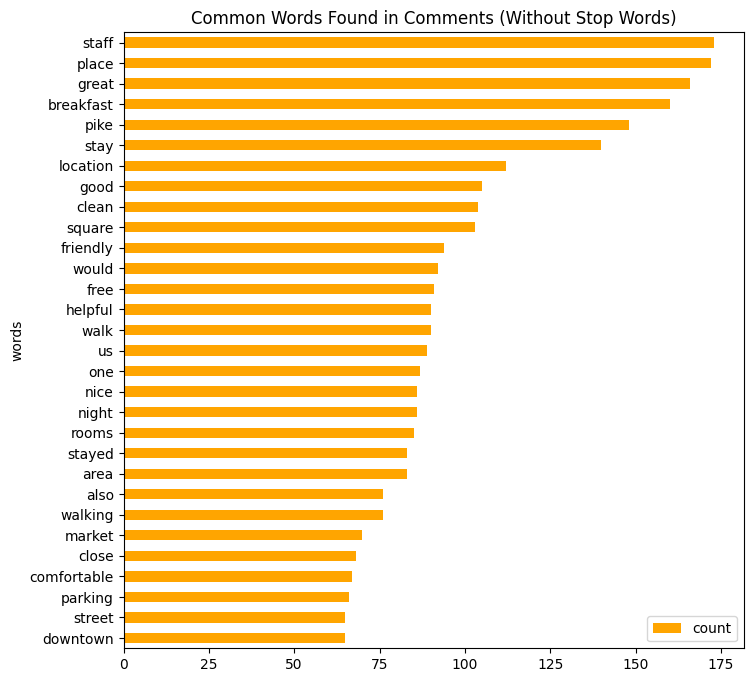

In [54]:
clean_words = pd.DataFrame(counts_all.most_common(30),
                             columns=['words', 'count'])
#clean_words

fig, ax = plt.subplots(figsize=(8, 8))

# Plot horizontal bar graph
clean_words.sort_values(by='count').plot.barh(x='words',
                      y='count',
                      ax=ax,
                      color="orange")

ax.set_title("Common Words Found in Comments (Without Stop Words)")

plt.show()

### Isolate reviews with specific words that you want to analyze

The example below is selecting only reviews with the word <b>'staff'</b>

In [55]:
select_comments = []
for comment in comments:
    temp = comment.lower()
    if 'staff' in temp:
        select_comments.append(temp)

# 145 comments contain the word staff
len(select_comments)

     

145

## Using TextBlob for sentiment analysis

__[TextBlob](https://textblob.readthedocs.io/en/dev/)__

### Sentiment Analysis

Sentiment property returns values of polarity and subjectivity.  The polarity score is a float that ranges from -1.0 to 1.0.  Typically a polarity score below -0.5 is negative, a score above 0.5 is positive and a score in between is considered neutral.

The subjectivity score is a float that ranges between 0.0 and 1.0 where the lower scores are very objective and the scores closer to 1.0 are very subjective.

In [56]:
comment_sent_pol = [TextBlob(review).sentiment.polarity for review in select_comments]
comment_sent_pol[:10]

[0.38504901960784316,
 0.3198809523809524,
 0.32708333333333334,
 0.10261111111111113,
 0.4734568903318903,
 0.25833333333333336,
 0.1346014492753623,
 0.2898809523809524,
 0.22289855072463774,
 0.1331547619047619]

In [57]:
len(comment_sent_pol)

145

Let us see how the sentiment polarity are distributed.  With `staff` being mentioned so many times, the Sandpiper Inn management wants to know if the comments are more positive or negative.

<div>
<img src = 'attachment:image.png', width = '500')
</div>

**NOTE:** Neutral polarity goes from -.5 to +.5.<br>

__[Reference of image](https://www.techscience.com/iasc/v35n1/48172/html)__

(array([ 1.,  1., 11., 22., 20., 38., 24., 14., 11.,  3.]),
 array([-0.11428571, -0.04061905,  0.03304762,  0.10671429,  0.18038095,
         0.25404762,  0.32771429,  0.40138095,  0.47504762,  0.54871429,
         0.62238095]),
 <BarContainer object of 10 artists>)

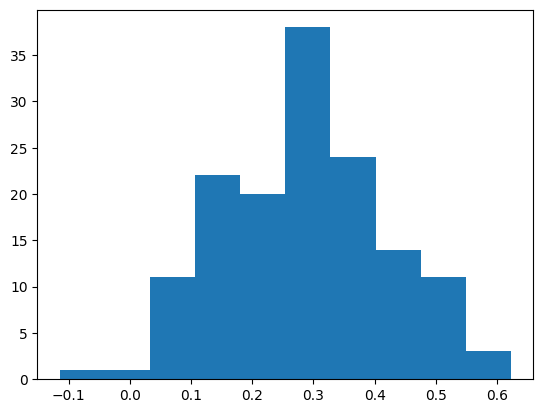

In [58]:
plt.hist(comment_sent_pol)

You can see by the histogram, which is relatively symmetric in shape, that all comments have a polarity above zero with some above 0.5. Even though there are few negative polarity scores, most lie between 0.1 and 0.5 indicating mostly **neutral reviews**.

<div class="alert alert-block alert-success"><b>Problem 7 (5 pts.)</b>:  
    
Isolate the comments containing at least one instance of the word <b>'homeless'</b>. 
1. Save the comments to a list and display the number of comments. You should have 13 comments.
2. Create a histogram to display the distribution of the average polarities. 
3. Using a `Markdown` cell, interpret the results.

</div>

<div class="alert alert-block alert-success"><b>Problem 7 (part 1)</b>:  
    
Save the comments to a list and display the number of comments. You should have 13 comments.
</div>

In [59]:
#ToDo: Create a list of comments that contain the word 'homeless'. Make sure the comments have already
# had punctuation removed and have been put into lowercase.
homeless_comments = []

for comment in comments:
    temp = comment.lower()
    if 'homeless' in temp:
        homeless_comments.append(temp)

#ToDo: Display the number of comments your list
len(homeless_comments)

13

<div class="alert alert-block alert-success"><b>Problem 7 (part 2)</b>:  
    
Create a histogram to display the distribution of the average polarities.
</div>

(array([1., 0., 2., 0., 6., 1., 1., 1., 0., 1.]),
 array([-0.11428571, -0.05314286,  0.008     ,  0.06914286,  0.13028571,
         0.19142857,  0.25257143,  0.31371429,  0.37485714,  0.436     ,
         0.49714286]),
 <BarContainer object of 10 artists>)

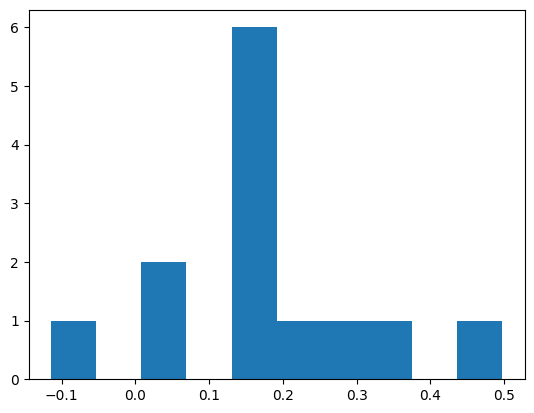

In [60]:
#ToDo: Show a histogram of the polarity
homeless_sent_pol = [TextBlob(review).sentiment.polarity for review in homeless_comments]
plt.hist(homeless_sent_pol)

<div class="alert alert-block alert-success"><b>Problem 7 (part 3)</b>:  
    
Using a `Markdown` cell, interpret the results.
</div>

**SD response:**

The histogram above shows us that the comments mentioning `homeless` have scores from ~`-0.11` to ~`+0.49`. Nearly all of them are positive, with only one having a slightly negative polarity. This is insightful as I would associate "homeless" with a negative sentiment especially in an urban context. But the data shows us that reviewers who reviewed the Sandpiper Inn and mentioned homeless people in the review are not saying anything negative about the stay. The polarity here is reflective of the entire review's tone and it seems like they mention it in the review of the Pike Place market area in general. 

The `staff` analysis was clearly more directional, with most polarity scores +0.3 or above, indicating that their stay was positive. I think reviewers are tempering the positive feedback when nothing something unpleasant about the area. Sandpiper Inn can interpret it this way: guests are clearly concerned with encountering homeless people but they are not reflecting badly on the hotel itself. 

## Stemming - getting to the root word

Stemming will take words such as `enjoyed` and `enjoying` to the root form of `enjoy`.  A disadvantage of stemming is that it may stem a word to a non-sensical word, such as `location` to `locat`.

Reference: __[Stemming vs Lemmatization](https://www.analyticsvidhya.com/blog/2022/06/stemming-vs-lemmatization-in-nlp-must-know-differences/)__

In [61]:
# Create a list of words 
to_stem = list(itertools.chain(*my_final))

# Stemming section
from nltk.stem.porter import PorterStemmer
porter = PorterStemmer()
stemmed = [porter.stem(word) for word in to_stem]
print(stemmed[:50])

['enjoy', 'husband', 'king', 'bed', 'clean', 'quiet', 'attract', 'son', 'twin', 'bed', 'corner', 'main', 'street', 'said', 'littl', 'noisier', 'neon', 'light', 'shone', 'later', 'hotel', 'trip', 'made', 'appreci', 'one', 'love', 'old', 'wood', 'center', 'staircas', 'breakfast', 'includ', 'everyon', 'happi', 'waffl', 'toast', 'cereal', 'egg', 'meal', 'locat', 'great', 'could', 'walk', 'shop', 'restaur', 'well', 'transport', 'pike', 'market', 'reason']


<div class="alert alert-block alert-success"><b>Problem 8 (6 pts.)</b>:  
    
When you look at the `stemmed` object above, you can see the results of using PorterStemmer.  But what did this do to our top words?
    
1. Write code to count the words and show the top 20 used.
2. Produce a new horizontal bar graph with this new set of words.
3. Using a `Markdown` cell, explain what stemming did to our set of words.

</div>

<div class="alert alert-block alert-success"><b>Problem 8 (part 1)</b>:  
    
Write code to count the words and show the top 20 used.
</div>

In [62]:
# ToDo: Count the words in stemmed
stemmed_count = collections.Counter(stemmed)

# ToDo: Display the top 20
stemmed_count.most_common(20)

[('stay', 251),
 ('walk', 203),
 ('place', 186),
 ('staff', 174),
 ('great', 166),
 ('breakfast', 164),
 ('locat', 162),
 ('pike', 158),
 ('night', 131),
 ('block', 111),
 ('help', 110),
 ('clean', 105),
 ('good', 105),
 ('squar', 103),
 ('nice', 96),
 ('friendli', 94),
 ('would', 92),
 ('free', 91),
 ('one', 90),
 ('us', 89)]

<div class="alert alert-block alert-success"><b>Problem 8 (part 2)</b>:  
    
Produce a new horizontal bar graph with this new set of words.
</div>

<Axes: ylabel='words'>

Text(0.5, 1.0, 'Common Words Found in Comments (Stemmed)')

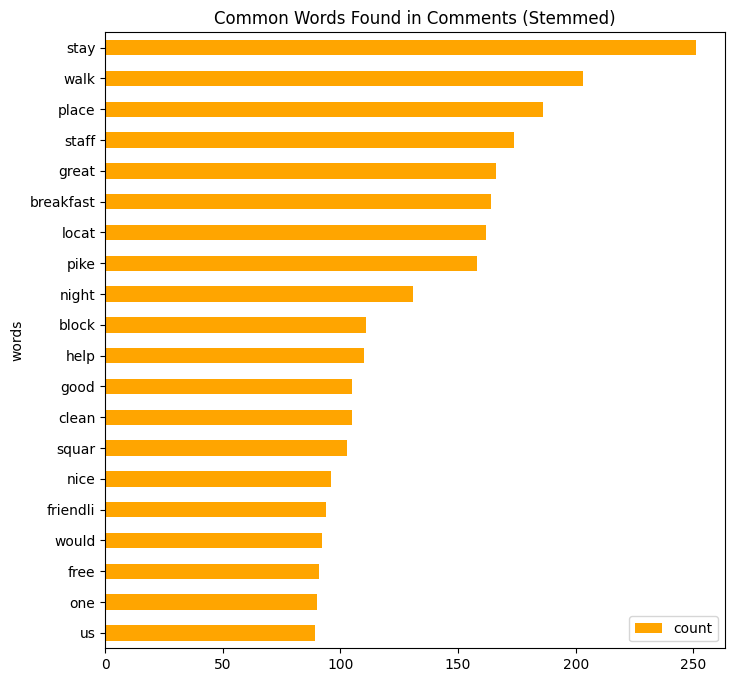

In [63]:
# ToDo: Create new horizontal bar chart with stemmed words
stemmed_count_clean = pd.DataFrame(stemmed_count.most_common(20), # Using same depth to show stemmed count's most common words
                             columns=['words', 'count'])

fig, ax = plt.subplots(figsize=(8, 8))

# Horizontal bar graph
stemmed_count_clean.sort_values(by='count').plot.barh(x='words',
                      y='count',
                      ax=ax,
                      color="orange")

ax.set_title("Common Words Found in Comments (Stemmed)")

plt.show()

<div class="alert alert-block alert-success"><b>Problem 8 (part 3)</b>:  
    
Using a `Markdown` cell, explain what stemming did to our set of words.

</div>

**SD Response:**

Using PorterStemmer drastically changed the top 20 list as it stripped characters to make it a root form of the word. `stay` becomes #1 jumping from 140 to 251. `walk` had a drastic change too from 90 to 203 occurrences. References to `location` also jumped 45% from 112 to 162. Certain free words like great, nice, free are unchanged as they have no major variants that straight counting could not catch. 

This actually succinctly demonstrates the advantages of stemming as it can look at root words rather than exact matches and it makes themes more visible for stakeholders. Guests frequently mention the stay, walking, the place, the staff, and breakfast. But it also shows the downside as some words became nonsensical: `locat`, `squar`, `friendli`. This is essentially why lemmatization was conceptualized so I would definitely prefer using it unless I was severely cost/compute constrained. 

## Lemmatization

We saw the limitations with stemming where the stemmed word may not be a meaningful representation of the word - like `squar` for `square`.  Lemmatization will overcome this problem as it looks for more meaningful representation of the word by looking at the entire sentence and considering context.  The result of lemmatization will be a valid word.
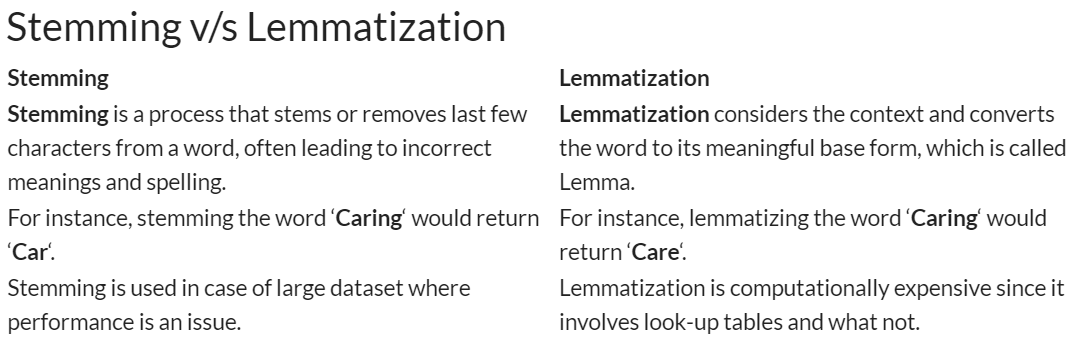

If you choose to go deeper into the programming of text analytics and NLP, you will learn more about stemming and lemmatization.  To see lemmatization code, check out: __[Stemming vs Lemmatization](https://www.analyticsvidhya.com/blog/2022/06/stemming-vs-lemmatization-in-nlp-must-know-differences/)__